In [1]:
import pycaret as pc

In [2]:
import pandas as pd 

In [3]:
data = pd.read_csv(r'C:\Users\Jeffersson Pretell\Documents\Especializacion_ML_Engineering\data\ds_credito_vehicular.csv')

In [18]:
data['default'].value_counts()

default
0    125
1     25
Name: count, dtype: int64

In [13]:
target = 'default'
categoricas = ['estado_civil','historia_credito']

In [11]:
from pycaret.classification import *

In [14]:
clasificar = setup(
                   data = data,
                   target = target,
                   session_id = 123,
                   normalize = True,
                   categorical_features = categoricas
                   )

,Description,Value
0,Session id,123
1,Target,default
2,Target type,Binary
3,Original data shape,"(150, 8)"
4,Transformed data shape,"(150, 12)"
5,Transformed train set shape,"(105, 12)"
6,Transformed test set shape,"(45, 12)"
7,Numeric features,5
8,Categorical features,2
9,Preprocess,True


In [27]:
data.select_dtypes(exclude = 'O').corr()

,edad,ingresos_mensuales,nro_creditos_previos,cuota_vs_ingreso,vehiculo_propio,default
edad,1.000000,-0.154900,0.130493,0.056728,-0.000378,0.097455
ingresos_mensuales,-0.154900,1.000000,0.123079,-0.117744,-0.108790,0.099068
nro_creditos_previos,0.130493,0.123079,1.000000,0.032333,-0.052128,-0.131916
cuota_vs_ingreso,0.056728,-0.117744,0.032333,1.000000,0.030221,0.141242
vehiculo_propio,-0.000378,-0.108790,-0.052128,0.030221,1.000000,-0.012244
default,0.097455,0.099068,-0.131916,0.141242,-0.012244,1.000000


<Axes: xlabel='ingresos_mensuales', ylabel='edad'>

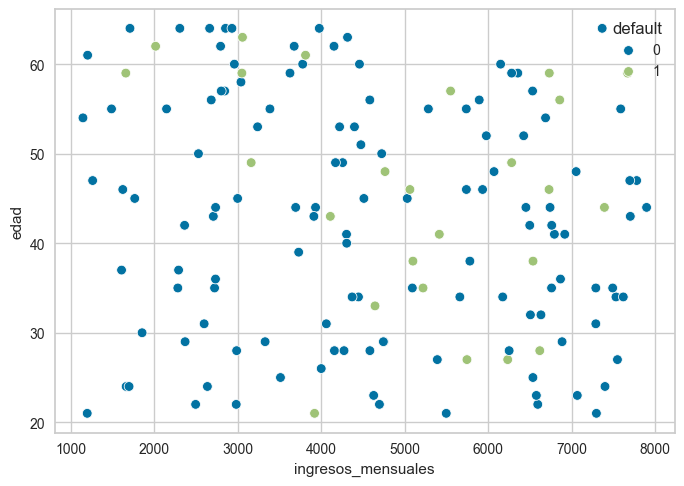

In [24]:
import seaborn as sns

sns.scatterplot(data = data,
                x = 'ingresos_mensuales',
                y = 'edad',
                hue = 'default')

In [15]:
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dummy,Dummy Classifier,0.8291,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0100
ridge,Ridge Classifier,0.8191,0.5049,0.0000,0.0000,0.0000,-0.0154,-0.0167,0.0130
rf,Random Forest Classifier,0.8100,0.4580,0.0000,0.0000,0.0000,-0.0292,-0.0316,0.0330
lr,Logistic Regression,0.7991,0.5035,0.0000,0.0000,0.0000,-0.0404,-0.0417,0.3080
lda,Linear Discriminant Analysis,0.7900,0.5049,0.0500,0.0500,0.0500,-0.0153,-0.0177,0.0100
lightgbm,Light Gradient Boosting Machine,0.7891,0.5993,0.0500,0.1000,0.0667,0.0013,0.0028,0.0440
knn,K Neighbors Classifier,0.7809,0.3132,0.0000,0.0000,0.0000,-0.0637,-0.0659,0.2100
gbc,Gradient Boosting Classifier,0.7527,0.5438,0.0500,0.0500,0.0500,-0.0639,-0.0687,0.0220
ada,Ada Boost Classifier,0.7473,0.5396,0.1000,0.0500,0.0667,-0.0384,-0.0365,0.0200
et,Extra Trees Classifier,0.7418,0.3854,0.0000,0.0000,0.0000,-0.1148,-0.1219,0.0260


In [20]:
SVM = create_model('svm') # Es el mejor modelo 

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5455,0.5000,0.0000,0.0000,0.0000,-0.2791,-0.2887
1,0.7273,0.5000,0.0000,0.0000,0.0000,-0.1379,-0.1491
2,0.8182,0.8889,0.5000,0.5000,0.5000,0.3889,0.3889
3,0.6364,0.6111,0.5000,0.2500,0.3333,0.1200,0.1336
4,0.8182,0.6667,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.8000,0.4444,0.0000,0.0000,0.0000,-0.1111,-0.1111
6,0.9000,0.8889,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.7000,0.4375,0.5000,0.3333,0.4000,0.2105,0.2182
8,0.7000,0.3750,0.0000,0.0000,0.0000,-0.1538,-0.1667


In [21]:
tuned_svm = tune_model(SVM)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8182,0.7222,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.8182,0.2222,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.8182,0.4444,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.8182,0.7778,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.8182,0.8333,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.9000,0.6667,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.9000,0.3333,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.8000,0.4375,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.8000,0.1875,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [22]:
evaluate_model(SVM)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…